# Download price history (Yahoo Finance)

Pulls **OHLCV candles** for a Yahoo Finance ticker -- any ticker `yfinance`
supports, not just an index -- and writes them to a timestamped CSV under
`data/`. Defaults to the NASDAQ 100 index (`^NDX`), daily candles.

Download logic lives in `trading_toolkit/yahoo_finance.py`, not in this notebook --
`download_history()` (wraps `yfinance`), `csv_path_for()`, `save_csv()`.

## Flow

| # | section | what happens |
| --- | --- | --- |
| 1 | **Parameters** | set `TICKER`, `PERIOD`, `INTERVAL` |
| 2 | **Download** | `yahoo_finance.download_history()` pulls OHLCV via `yfinance` |
| 3 | **Save** | write `data/yahoo_<ticker-slug>_<interval>_<timestamp>.csv` |
| 4 | **Preview** | `tail(10)` / `describe()` + a close-price chart |

## Note on the CSV shape

Yahoo Finance has no bid/ask -- this CSV is a single `Open`/`High`/`Low`/
`Close`/`Volume` series, unlike the IG pipeline's bid/ask/mid columns
(`trading_toolkit/constants/ig_csv_headers.py`). It is **not** compatible with
`02_ig_import_csv_to_db.ipynb` and isn't meant to feed `data/ig_market_data.db`.

**Prerequisite:** the `trading_toolkit` package installed -- `uv sync --extra dev`
from the repo root. That brings in `yfinance` (download) and `pandas` /
`matplotlib` (preview/chart; section 4 degrades gracefully if they're
missing).

## 1. Parameters

No `.env` involved -- edit these directly and re-run.

- **`TICKER`** -- Yahoo Finance ticker, e.g. `YahooTicker.NASDAQ_100` --
  `trading_toolkit/constants/yahoo_tickers.py`'s `YahooTicker` class -- see
  that module (or `doc/yahoo/yahoo-finance.md`) for other common indexes. Any
  ticker `yfinance` supports also works as a plain string.
- **`PERIOD`** -- how much history to pull, e.g. `YahooPeriod.YTD` --
  `trading_toolkit/constants/yahoo_periods.py`'s `YahooPeriod` class (plain
  `yfinance` period strings, asserted below against its `VALID_PERIODS`).
- **`INTERVAL`** -- candle size, e.g. `YahooInterval.DAY_1` --
  `trading_toolkit/constants/yahoo_intervals.py`'s `YahooInterval` class
  (asserted below against its `VALID_INTERVALS`). Intraday intervals only
  cover recent history -- Yahoo limits how far back sub-daily data goes.

In [ ]:
from trading_toolkit.constants.yahoo_tickers import YahooTicker
from trading_toolkit.constants.yahoo_periods import YahooPeriod, VALID_PERIODS
from trading_toolkit.constants.yahoo_intervals import YahooInterval, VALID_INTERVALS

TICKER = YahooTicker.DAX40  # see constants/yahoo_tickers.py for other indexes
PERIOD = YahooPeriod.MAX       # how much history to pull, see constants/yahoo_periods.py
INTERVAL = YahooInterval.DAY_1   # candle size, see constants/yahoo_intervals.py

assert PERIOD in VALID_PERIODS, f"PERIOD must be one of {VALID_PERIODS}, got {PERIOD!r}"
assert INTERVAL in VALID_INTERVALS, f"INTERVAL must be one of {VALID_INTERVALS}, got {INTERVAL!r}"

import sys
print(sys.executable)

print(f"TICKER={TICKER!r}  PERIOD={PERIOD!r}  INTERVAL={INTERVAL!r}")

C:\repos\github.com\jupyter-notebooks\.venv\Scripts\python.exe
TICKER='^DJI'  PERIOD='max'  INTERVAL='1d'


## 2. Download

`yahoo_finance.download_history()` (`trading_toolkit/yahoo_finance.py`) wraps
`yfinance.Ticker(TICKER).history(period=PERIOD, interval=INTERVAL)`, dropping
the `Dividends`/`Stock Splits` columns (an index has neither) and raising if
Yahoo returns no rows.

In [2]:
from trading_toolkit.yahoo_finance import download_history

df = download_history(TICKER, period=PERIOD, interval=INTERVAL)

print(f"{len(df)} {INTERVAL} candles for {TICKER}")
print(f"  range: {df.index[0]}  ->  {df.index[-1]}")
df.tail(5)

8740 1d candles for ^DJI
  range: 1992-01-02 00:00:00-05:00  ->  2026-09-18 00:00:00-04:00


,Open,High,Low,Close,Volume
Date,,,,,
2026-09-14 00:00:00-04:00,52750.878906,52750.878906,52278.890625,52421.199219,442650000
2026-09-15 00:00:00-04:00,52303.238281,52336.609375,51875.648438,52093.109375,374460000
2026-09-16 00:00:00-04:00,52115.398438,52173.699219,51186.671875,51461.898438,395270000
2026-09-17 00:00:00-04:00,51882.531250,51935.968750,51607.648438,51778.039062,406100000
2026-09-18 00:00:00-04:00,51826.781250,51826.781250,51497.468750,51682.640625,846980000


## 3. Save to CSV

Always written (no `SAVE_CSV` toggle here) to a fresh, timestamped path under
`data/`: `csv_path_for()` builds `data/yahoo_<ticker-slug>_<interval>_<timestamp>.csv`
(`^NDX` -> `nasdaq100`, via `constants/yahoo_ticker_slugs.py`'s `TICKER_SLUGS`),
and `save_csv()` writes `df` there, indexed by date.

In [3]:
from trading_toolkit.yahoo_finance import csv_path_for, save_csv

CSV_PATH = csv_path_for(TICKER, INTERVAL)
save_csv(df, CSV_PATH)

print(f"wrote {CSV_PATH.resolve()}  ({len(df)} rows)")

wrote C:\repos\github.com\jupyter-notebooks\data\yahoo_dowjones_1d_20260921161602.csv  (8740 rows)


## 4. Preview + close chart

Needs `pandas` (already used above) and `matplotlib`
(`%pip install matplotlib`). A tail-10 table + `describe()`, then a close
line chart with a shaded high/low band.

In [4]:
if df.empty:
    print(f"Download returned 0 {INTERVAL} candles for {TICKER} - nothing to preview.")
else:
    display(df.tail(10))
    display(df.describe())

,Open,High,Low,Close,Volume
Date,,,,,
2026-09-04 00:00:00-04:00,53584.890625,53635.351562,53289.878906,53414.250000,381130000
2026-09-08 00:00:00-04:00,53110.449219,53110.449219,52721.621094,52786.070312,417970000
2026-09-09 00:00:00-04:00,52707.898438,52707.898438,52314.609375,52380.660156,403100000
2026-09-10 00:00:00-04:00,52291.851562,52291.851562,51962.710938,52064.101562,397900000
2026-09-11 00:00:00-04:00,52204.460938,52720.238281,52204.460938,52573.289062,354460000
2026-09-14 00:00:00-04:00,52750.878906,52750.878906,52278.890625,52421.199219,442650000
2026-09-15 00:00:00-04:00,52303.238281,52336.609375,51875.648438,52093.109375,374460000
2026-09-16 00:00:00-04:00,52115.398438,52173.699219,51186.671875,51461.898438,395270000
2026-09-17 00:00:00-04:00,51882.531250,51935.968750,51607.648438,51778.039062,406100000


,Open,High,Low,Close,Volume
count,8740.000000,8740.000000,8740.000000,8740.000000,8.740000e+03
mean,16590.122911,16686.165918,16491.016311,16593.897104,2.153064e+08
std,11732.914200,11790.395580,11673.908007,11734.575862,1.547533e+08
min,3136.600098,3172.629883,3095.790039,3136.600098,8.410000e+06
25%,9092.812256,9164.634766,9034.862549,9096.067383,8.604500e+07
50%,11538.760254,11616.570312,11462.589844,11542.550293,2.071100e+08
75%,23534.830566,23603.031738,23354.615234,23515.509766,3.017500e+08
max,54426.851562,54744.328125,54266.121094,54349.121094,1.412960e+09


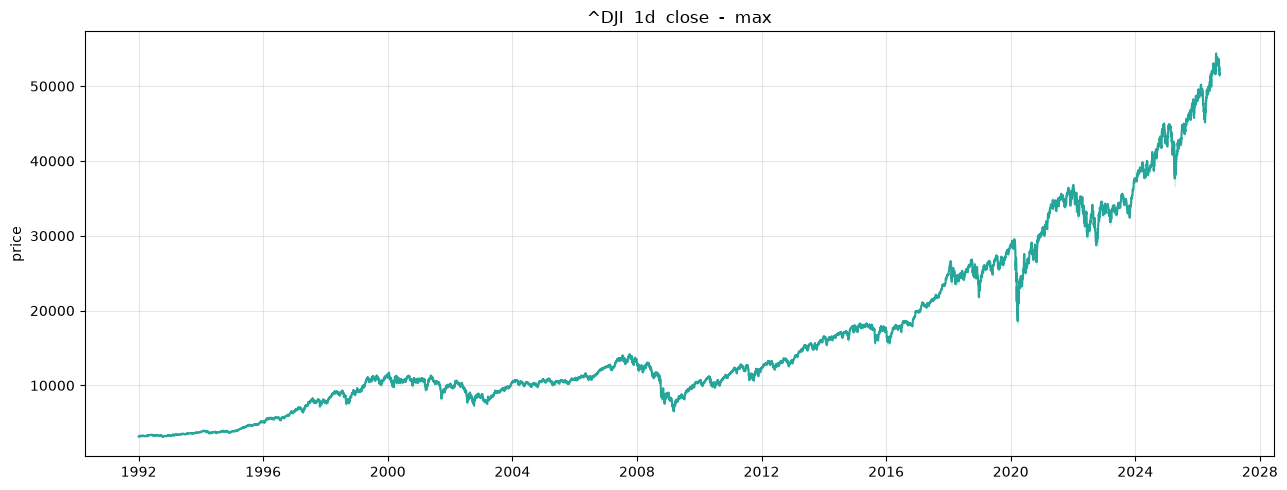

In [5]:
if df.empty:
    print("Nothing to plot.")
else:
    try:
        import matplotlib.pyplot as plt
    except ModuleNotFoundError:
        print("matplotlib not installed - run:  %pip install matplotlib")
    else:
        fig, ax = plt.subplots(figsize=(13, 5))
        ax.plot(df.index, df["Close"], color="#26a69a")
        ax.fill_between(df.index, df["Low"], df["High"], color="#26a69a", alpha=0.15)
        ax.set_title(f"{TICKER}  {INTERVAL}  close  -  {PERIOD}")
        ax.set_ylabel("price")
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()